In [57]:
import numpy as np
import pandas as pd

# 2.2 data preparation

## load dataset

In [58]:
data = 'https://raw.githubusercontent.com/alexeygrigorev/mlbookcamp-code/master/chapter-02-car-price/data.csv'

In [59]:
df = pd.read_csv('data.csv')

df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fixed of column name

In [60]:
# dataset er column name gulay jhamela eta thik korbo

df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='object')

In [61]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


## inconsistent data fix of values

In [62]:
# column name fixed. ekhon value gula fix kora lagbe.
df.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [63]:
df.dtypes == 'str'

make                 False
model                False
year                 False
engine_fuel_type     False
engine_hp            False
engine_cylinders     False
transmission_type    False
driven_wheels        False
number_of_doors      False
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [64]:
df.dtypes[df.dtypes == 'str']

Series([], dtype: object)

In [65]:
# upore je dataframe paisi tar make,model,... eigula hoilo index and str,str,... eigula hoilo value.
# index gulare niya list e convert korbo jate loop chalaite pari.


strings = df.dtypes[df.dtypes == 'str'].index.tolist() # .tolist()  diye list e convert korlam

strings

[]

In [66]:
for x in strings:
    df[x] = df[x].str.lower().str.replace(' ', '_')

In [67]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [68]:
# awesome. column names and values all are fixed.

# 2.3 Exploratory data analysis

In [69]:
# first amader protita column e koyta unique value ase and ki ki(minimum 5 ta) check korte hobe.
# numerical and categorical both column check korte hobe. this is a part of eda. 

for x in df.columns:
    print(x)
    print(df[x].unique()[:5])
    print(df[x].nunique())
    print('-------------------')
    print()

make
['BMW' 'Audi' 'FIAT' 'Mercedes-Benz' 'Chrysler']
48
-------------------

model
['1 Series M' '1 Series' '100' '124 Spider' '190-Class']
915
-------------------

year
[2011 2012 2013 1992 1993]
28
-------------------

engine_fuel_type
['premium unleaded (required)' 'regular unleaded'
 'premium unleaded (recommended)' 'flex-fuel (unleaded/E85)' 'diesel']
10
-------------------

engine_hp
[335. 300. 230. 320. 172.]
356
-------------------

engine_cylinders
[ 6.  4.  5.  8. 12.]
9
-------------------

transmission_type
['MANUAL' 'AUTOMATIC' 'AUTOMATED_MANUAL' 'DIRECT_DRIVE' 'UNKNOWN']
5
-------------------

driven_wheels
['rear wheel drive' 'front wheel drive' 'all wheel drive'
 'four wheel drive']
4
-------------------

number_of_doors
[ 2.  4.  3. nan]
3
-------------------

market_category
['Factory Tuner,Luxury,High-Performance' 'Luxury,Performance'
 'Luxury,High-Performance' 'Luxury' 'Performance']
71
-------------------

vehicle_size
['Compact' 'Midsize' 'Large']
3
-------------

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

In [71]:
df.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


<Axes: xlabel='msrp', ylabel='Count'>

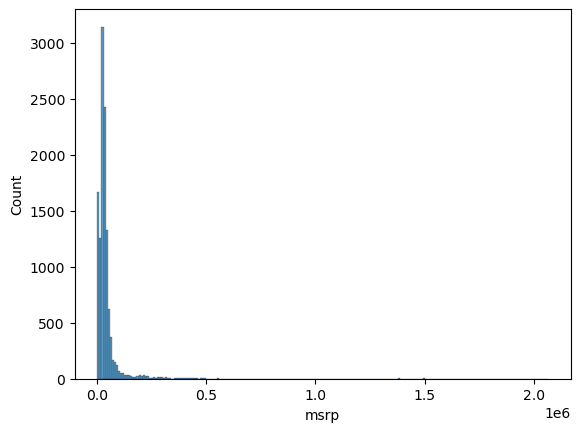

In [72]:
sns.histplot(data=df, x='msrp')

<Axes: xlabel='msrp', ylabel='Count'>

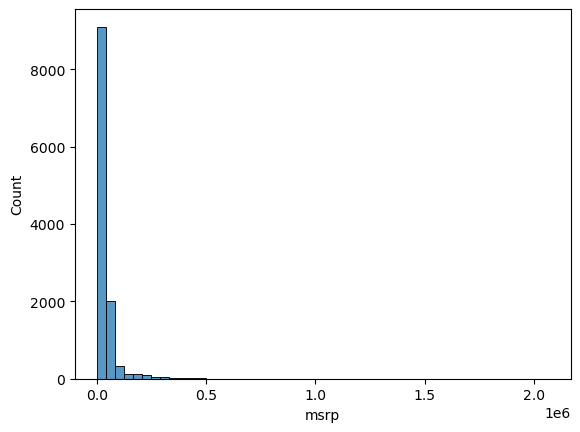

In [73]:
sns.histplot(data = df, x='msrp', bins=50)

# nicher graph ta dekho x axis e msrp dewa ase 1e6 diye. mane 1 er por 6 ta zero, mane 10 lakh. 
# that means ei graph e 0, 5 lakh, 10 lakh, 15 lakh, 20 lakh dollar er range ase. 

# nicher graph ta dekhe bojha jay 0 theke 3 lakh er moddhe density beshi.

<Axes: xlabel='msrp', ylabel='Count'>

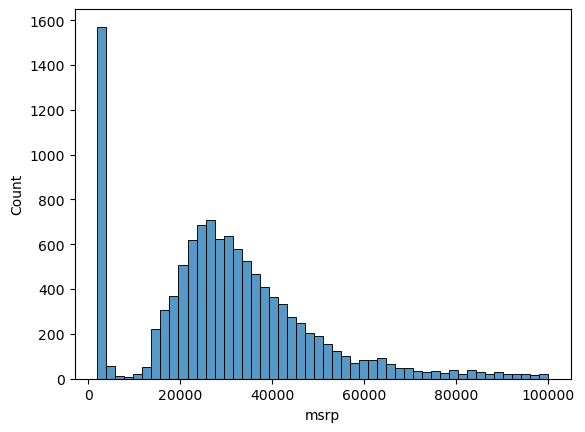

In [74]:
# ekhn ami condition diye price range komaya dibo.
sns.histplot(data = df[df.msrp < 100000], x='msrp', bins=50)

In [75]:
# uporer graph theke bujhlam eta right skewed. and linear regression er jonne bell shaped (normal distribution) data dorkar.

# and etar jonne amader log-normal distribution apply korte hobe.

# nicher code ta just sample ekta code. protita value 10x kore beshi. parthokko 99, 999, 9999,... but jokhon log e convert kore nichi tokhon difference onek kome gese. 

np.log([1, 100, 1000, 10000])

array([0.        , 4.60517019, 6.90775528, 9.21034037])

In [76]:
# but log er vitore 0 thakle error dibe. so, amra log1p use korbo. log1p mane log(1+x). so, 0 thakleo sheta 1 hoye jabe and error dibe na.

np.log1p([1, 100, 1000, 10000])

array([0.69314718, 4.61512052, 6.90875478, 9.21044037])

<Axes: xlabel='msrp', ylabel='Count'>

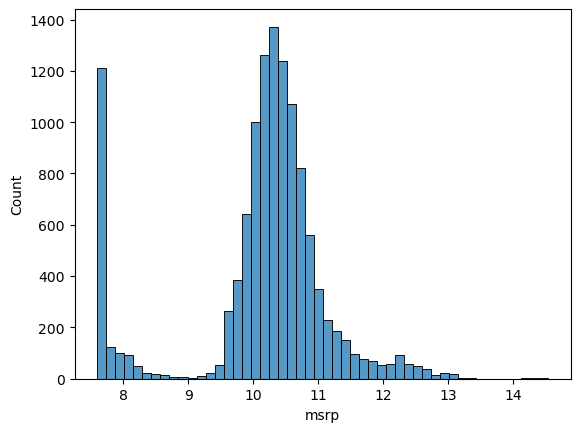

In [77]:
# ekhon msrp er value gular difference jehetu onek beshi tai ami log1p kore felbo.
# log1p use korle duita jinish hoy. 1. data ta normal distribution e convert hoye jabe. 2. data er difference onek choto hoye jabe.

price_log = np.log1p(df.msrp)

sns.histplot(data = price_log, bins=50)

In [78]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 - the validation framework

In [79]:
# ekhn full dataset ke train, validation and test e split korte hobe. 60% train, 20% validation and 20% test.
# but first e suffle kore newa lagbe karon dataset kono ekta feature er upor sorted thakte pare.
# eta numpy, pandas and sklearn diye kora jay. numpy fast, pandas easy and sklearn fast + easy. but numpy er theke khub ekta easy na. so ami always numpy diyei korbo.

# so steps are: 1. suffle, 2. size calculation, 3. split    -> split korai main target but split korar jonnei suffle and size calculation korte hobe.


# and then finally feature matrix(input) and target variable(output) banabo from train data.

pass

### dataset shuffle 

In [80]:
# etar maddhome dataset e total row number dekhte pabo.
n = len(df)

n

11914

In [81]:
# স্টেপ ১: Shuffle (পুরো ডেটাসেট শাফেল করা)
np.random.seed(2)

idx = np.arange(len(df)) # dtaset e total 11914 ta row ase. idx er moddhe 0 to 11913 porjonto serially number gula numpy array hishebe ase.

np.random.shuffle(idx) # ekhon idx er moddhe 0 to 11913 porjonto number gula random order e ase. mane shafle kora hoise.

df_shuffled = df.iloc[idx].reset_index(drop=True)  # ekhon iloc diye dataset e shafle kora index gula diye row gula select kora hoise. and reset_index diye index 0 theke start kora hoise. drop=True means main dataset er index ei change kora hoilo.

### dataset er size calculation

In [82]:
n = len(df_shuffled)

n

11914

In [83]:
# ekhon 11914 ta row er 20 percent validation, 20 percent test and baki rows(nearly 60 percent) train e split kora hobe.
# ei code gulay split kora hoy nai. just 20 percent e koyta row hoy shei number ta store kora hoise. ei number split e kaje lagbe.

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

### split

In [84]:
n_train, n_val, n_test

(7150, 2382, 2382)

In [85]:
df_train = df_shuffled.iloc[:n_train]  # prothom 7150(0 to 7149) ta row train data hishebe nilam

df_val = df_shuffled.iloc[n_train : n_train + n_val] # 7150 : 9532(7150 + 2382) ta row validation data hishebe nilam 

df_test = df_shuffled.iloc[n_train + n_val :] # # 9532 : 11914(9532 + 2382) ta row test data hishebe nilam

### feature matrix and target variable

In [86]:
# first e train, validation and test dataset theke target variable(y) msrp alada korbo.

df_train['msrp']

0        14410
1        19685
2        19795
3         2000
4        56260
         ...  
7145     54900
7146     29215
7147     34675
7148    303300
7149     37820
Name: msrp, Length: 7150, dtype: int64

In [87]:
# upore dekhtei partesi ekta column select korle oita pandas series return kore and index ow thake. index amar kaje lagbe na. just values gula kaje lagbe. so, ami to_numpy() use kore numpy array e convert korbo.

df_train['msrp'].to_numpy()

array([ 14410,  19685,  19795, ...,  34675, 303300,  37820], shape=(7150,))

In [88]:
# now 'EDA' te dekhsi msrp er value gulare normal distribution e convert korar jonne log transformation korte hobe.

# y_train, y_val, y_test er moddhe msrp(target variable, y) er log transformed value store ase.

y_train = np.log1p(df_train['msrp'].to_numpy())
y_val = np.log1p(df_val['msrp'].to_numpy())
y_test = np.log1p(df_test['msrp'].to_numpy())

In [89]:
# ekhon main dataset(df_train, df_val, df_test) theke msrp column ta delete kore dibo. taholei ami feature matrix(input) pabo.

# delete korar por df_train, df_val, df_test ei holo feature matrix.

del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

# 2.5 - Linear Regression

In [90]:
df_train.head()

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Chevrolet,Cobalt,2008,regular unleaded,148.0,4.0,MANUAL,front wheel drive,2.0,NaN,Compact,Coupe,33,24,1385
1,Toyota,Matrix,2012,regular unleaded,132.0,4.0,AUTOMATIC,front wheel drive,4.0,Hatchback,Compact,4dr Hatchback,32,25,2031
2,Subaru,Impreza,2016,regular unleaded,148.0,4.0,AUTOMATIC,all wheel drive,4.0,Hatchback,Compact,4dr Hatchback,37,28,640
3,Volkswagen,Vanagon,1991,regular unleaded,90.0,4.0,MANUAL,rear wheel drive,3.0,NaN,Large,Passenger Minivan,18,16,873
4,Ford,F-150,2017,flex-fuel (unleaded/E85),385.0,8.0,AUTOMATIC,four wheel drive,4.0,Flex Fuel,Large,Crew Cab Pickup,21,15,5657


In [91]:
# ekhon jekono eka row select korbo.

df_train.iloc[10]

make                                 Rolls-Royce
model                     Phantom Drophead Coupe
year                                        2015
engine_fuel_type     premium unleaded (required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      AUTOMATIC
driven_wheels                   rear wheel drive
number_of_doors                              2.0
market_category        Exotic,Luxury,Performance
vehicle_size                               Large
vehicle_style                        Convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 10, dtype: object

In [92]:
# uporer row theke ami engine_hp(453), city_mpg(11), popularity(86) ei feature gula input(feature matrix) hishebe use korbo.
xi = [453, 11, 86]       

# ekhon bias term and weights gula apatoto nijera dhore nitesi. eigula ber korar way pore shikhbo.
w0 = 7.17                # Bias term
w = [0.01, 0.04, 0.002]  # weights


# xi, w0 and w er estimated value gula log transformed msrp er jonnei predict kore dhora hoise. tai model theke jei price output pabo oita log transformed msrp hobe.

In [93]:
def linear_regression(xi):
    pred = w0

    n = len(xi)
    for j in range(n):
        pred = pred + w[j] * xi[j]
        
    return pred

pred_result = linear_regression(xi)
pred_result

12.312

In [94]:
# uporer jei result ta paisi oita log transformed value. etake actual price e convert korte exponential kora lagbe.

actual_price = np.expm1(pred_result)
actual_price

np.float64(222347.2221101062)

# 2.6 - Linear Regression Vector form

In [95]:
# multiple car er features gula numpy array te converte kora holo. imp: protiti feature e 1 extra hishebe arrayte add kora ase for bias term added in weight numpy array

# Three cars
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

# Feature matrix
X = np.array([x1, x2, x10])

X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [96]:
# Bias term
w0 = 7.17

# protita features er jonne weigh lagbe
w = [0.01, 0.04, 0.002]

# now bias + weight
w_new = [w0] + w

w_new

[7.17, 0.01, 0.04, 0.002]

In [97]:
# Linear Regression for all cars
def linear_regression(X):
    return X.dot(w_new)

linear_regression(X) # output predicted price log transformed value ashbe.

array([12.38 , 13.552, 12.312])

# 2.7 - training linear regression

### explanatio

In [98]:
# ekhon w0(bias term) and w(weights) ber korbo. eta ber korar jonne amader equation use korte hobe.

# equation er details 2.7_training_linear_regression.ipynb note ta dekho.

# first e feature matrix(X) and target variable(y) banabo

X = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
], dtype=float)

y = np.array([
    100, 200, 150, 250, 100,
    200, 150, 250, 120
], dtype=float)

print(X.shape, y.shape) # X er shape 9x3 and y er shape 9x1

(9, 3) (9,)


In [99]:
# equation: w = (X^T * X)^-1 * X^T * y

# first e gram matrix: X.T * X -> XTX
XTX = X.T @ X

XTX.shape

(3, 3)

In [100]:
# second: gram matrix ke inverse: (X^T * X)^-1 -> XTX_inv
XTX_inv = np.linalg.inv(XTX)

# inverse thik ase kina eta check korar jonne amtra main or gram matrix(XTX) inverse kore dekhbo identity matrix pai kina. karon A*A^-1 = I (identity matrix).
identity_check = XTX.dot(XTX_inv).round(1)
identity_check

array([[ 1.,  0., -0.],
       [-0.,  1.,  0.],
       [ 0.,  0.,  1.]])

In [101]:
# equation: w = (X^T * X)^-1 * X^T * y

# (X.T * X)^-1   ->   done (XTX_inv)
# X.T * y   ->   korbo

XTy = X.T @ y

print(XTy.shape)
print(XTy)

(3,)
[344010.  37820. 786970.]


In [102]:
# equation: w = (X^T * X)^-1 * X^T * y

# (X.T * X)^-1   ->   done (XTX_inv)
# X.T * y   ->   done (XTy)

# ekhon equation er last part: w = (X^T * X)^-1 * X^T * y


w_full = XTX_inv.dot(XTy) # w_full tai holo w.

w_full

array([0.26190562, 3.06101252, 0.03696909])

In [103]:
# but jhamela hoitese . w_full array te first term mane w0 hobe bias term. but ekhane bias term pabo na. karon X matrix e e 1 add kora hoy nai. so oita korte hobe.

X.shape

(9, 3)

In [104]:
# ekhon uporer dekhlam 9 ta row ase. tai amar 9 ta 1 lagbe. but ami X.shpape[0] dilei row peye jabo.


# Add the bias column of 1s
ones = np.ones(X.shape[0])
X = np.column_stack([ones, X])

pass

# but eta chalaya lav nai karon ones aagei add kora lagto. then baki shob abar run kora lagbe.

### all codes serially

In [105]:
# Normal Equation

XTX = X.T.dot(X)                  # Gram Matrix
XTX_inv = np.linalg.inv(XTX)      # Gram Matrix inverse
XTy = X.T.dot(y)

w_full = XTX_inv.dot(XTy)

# First value = bias, rest = feature weights
w0 = w_full[0]
w = w_full[1:]

print("Bias w0:", w0)
print("Feature weights w:", w)


Bias w0: 300.06776692555616
Feature weights w: [-0.22774253 -2.5769413  -0.02301206]


### final function

In [106]:
def train_linear_regression(X, y):
    # Add bias column
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    # Normal Equation
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    # Split bias and feature weights
    return w_full[0], w_full[1:]


In [107]:
# Original feature matrix without the bias column
X_features = np.array([
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86],
    [38,  54, 185],
    [142, 25, 431],
    [453, 31, 86],
], dtype=float)

y = np.array([
    100, 200, 150, 250, 100,
    200, 150, 250, 120
], dtype=float)

w0, w = train_linear_regression(X_features, y)

print("Bias w0:", w0)
print("Feature weights w:", w)

Bias w0: 300.06776692555616
Feature weights w: [-0.22774253 -2.5769413  -0.02301206]


# 2.8 - Baseline Model

In [109]:
df_train.dtypes

make                  object
model                 object
year                   int64
engine_fuel_type      object
engine_hp            float64
engine_cylinders     float64
transmission_type     object
driven_wheels         object
number_of_doors      float64
market_category       object
vehicle_size          object
vehicle_style         object
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [110]:
# baseline model train er jonne ami just koyekta numerical column nibo. numerical column: engine_hp, engine_cylinders, highway_mpg, city_mpg, popularity. target variable: msrp.

base = ['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

df_train[base]

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,148.0,4.0,33,24,1385
1,132.0,4.0,32,25,2031
2,148.0,4.0,37,28,640
3,90.0,4.0,18,16,873
4,385.0,8.0,21,15,5657
...,...,...,...,...,...
7145,300.0,6.0,31,20,3916
7146,210.0,4.0,30,24,873
7147,285.0,6.0,22,17,549
7148,563.0,12.0,21,13,86


In [112]:
# ami index and column name gula bad dibo
df_train[base].values

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [113]:
x_train = df_train[base].values
x_train 

array([[ 148.,    4.,   33.,   24., 1385.],
       [ 132.,    4.,   32.,   25., 2031.],
       [ 148.,    4.,   37.,   28.,  640.],
       ...,
       [ 285.,    6.,   22.,   17.,  549.],
       [ 563.,   12.,   21.,   13.,   86.],
       [ 200.,    4.,   31.,   22.,  873.]], shape=(7150, 5))

In [114]:
y_train

array([ 9.57574708,  9.887663  ,  9.89323518, ..., 10.45380308,
       12.62248099, 10.54061978], shape=(7150,))

In [115]:
# ekhon 2.8 e jei train_linear_regression function ta banaisi, oita use kore ami w0 and w ber korbo. and then linear_regression function e w0 and w use kore predicted price ber korbo.

train_linear_regression(x_train, y_train)

(np.float64(nan), array([nan, nan, nan, nan, nan]))

In [116]:
# train_linear_regression function theke shob null paisi karon ami jei feature matrix(x_train) disi oikhane NaN value ase.

df_train[base].isnull().sum()

engine_hp           40
engine_cylinders    14
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [120]:
# amra currenly missing value gulare 0 diye fill kore dibo. jodio eta preferable na. mean or median diye fill kora better. but ekhn simplicity rakhar jonne 0 diye fill korbo.
x_train = df_train[base].fillna(0).values

df_train[base].isnull().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [121]:
train_linear_regression(x_train, y_train)

(np.float64(7.927257388070121),
 array([ 9.70589522e-03, -1.59103494e-01,  1.43792133e-02,  1.49441072e-02,
        -9.06908672e-06]))

In [122]:
# uporer first value ta holo w0 and array ta holo w.
# ekhon ei w0 and w use kore ami linear_regression function e predicted price ber korbo.

w0, w = train_linear_regression(x_train, y_train)

print("Bias w0:", w0)
print("Feature weights w:", w)

Bias w0: 7.927257388070121
Feature weights w: [ 9.70589522e-03 -1.59103494e-01  1.43792133e-02  1.49441072e-02
 -9.06908672e-06]


In [123]:
# ekhon ei w0 and w linear_regression er function e pass korte hobe. but ekhon r function e pass na kore ami direct formula te boshaya ditesi.
# formula : y = w0 + x.w  -> here x = x_train

y_pred = w0 + x_train.dot(w)

y_pred

array([ 9.54792783,  9.38733977,  9.67197758, ..., 10.30423015,
       11.9778914 ,  9.99863111], shape=(7150,))

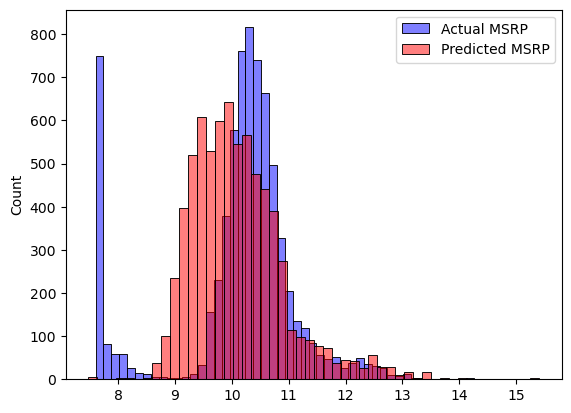

In [126]:
# ekhon ami real msrp (y_train) and predicted msrp (y_pred) er moddhe difference ta histplot diye dekhbo.

sns.histplot(data=y_train, color='blue', label='Actual MSRP', bins=50, alpha=0.5)
sns.histplot(data=y_pred, color='red', label='Predicted MSRP', bins=50, alpha=0.5)
plt.legend()
plt.show()